# Kỹ Nghệ Đặc Trưng (Feature Engineering) - Tập dữ liệu CEAS_08.csv

Notebook này thực hiện quy trình Kỹ nghệ đặc trưng (Feature Engineering) và Lựa chọn đặc trưng (Feature Selection) tinh gọn theo phương pháp thống kê Chi-Square.

In [1]:
import pandas as pd
import numpy as np

# Tải dữ liệu từ tập CEAS_08.csv
data = pd.read_csv("../data/raw/CEAS_08.csv")
print(f"Kích thước dữ liệu thô: {data.shape[0]} hàng, {data.shape[1]} cột")

Kích thước dữ liệu thô: 39154 hàng, 7 cột


In [2]:
# Tính toán các thuộc tính cơ bản trước khi xử lý (độ dài từ và ký tự)
data['body'] = data['body'].fillna('')
data['subject'] = data['subject'].fillna('')
data['body_len_words'] = data['body'].apply(lambda x: len(x.split()))
data['body_len_chars'] = data['body'].apply(len)
print("Đã khởi tạo các thuộc tính cơ bản: body_len_words, body_len_chars")

Đã khởi tạo các thuộc tính cơ bản: body_len_words, body_len_chars


## Bước 1. Xử Lý Giá Trị Thiếu (Handling Missing Values)

In [3]:
# 1. Điền khuyết dữ liệu
data['receiver'] = data['receiver'].fillna('Unknown')
data['subject'] = data['subject'].fillna('')
data['body'] = data['body'].fillna('')
print("Hoàn thành xử lý giá trị thiếu.")

Hoàn thành xử lý giá trị thiếu.


## Bước 2. Xử Lý Giá Trị Ngoại Lệ (Handling Outliers)

Skewness trước biến đổi: 12.8894
Skewness sau biến đổi: -0.0511


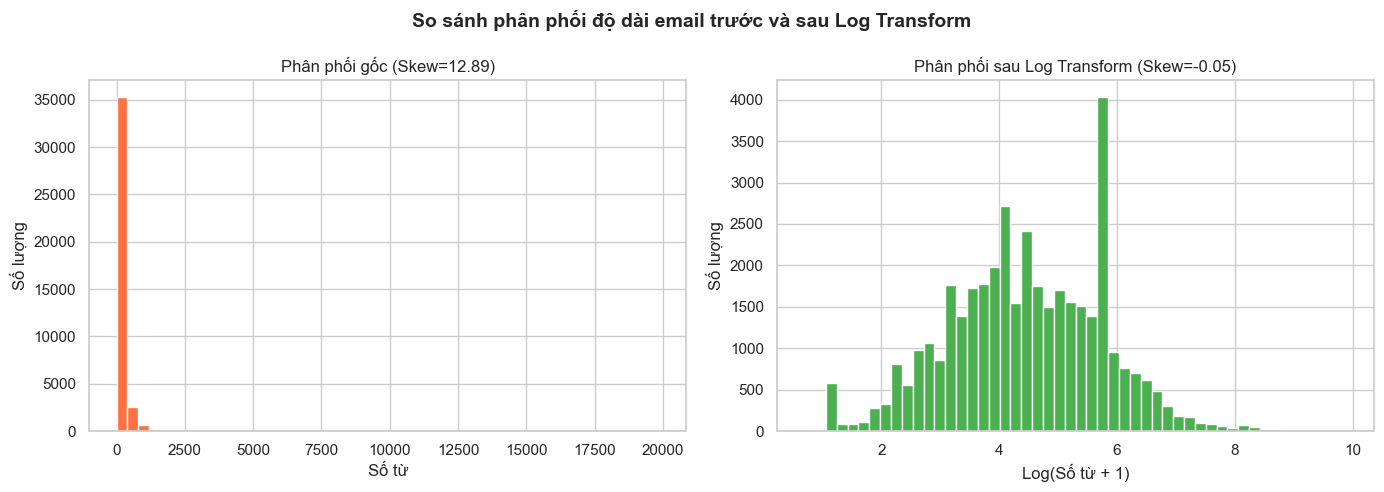

In [4]:
# 2. Áp dụng phép biến đổi Log(x + 1) cho cột body_len_words để giảm skewness
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

data['body_len_words_log'] = np.log1p(data['body_len_words'])

skew_before = data['body_len_words'].skew()
skew_after = data['body_len_words_log'].skew()

print(f"Skewness trước biến đổi: {skew_before:.4f}")
print(f"Skewness sau biến đổi: {skew_after:.4f}")

# Trực quan hóa phân phối trước và sau biến đổi (2 biểu đồ)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(data['body_len_words'], bins=50, color='#FF7043', edgecolor='white')
axes[0].set_title(f'Phân phối gốc (Skew={skew_before:.2f})')
axes[0].set_xlabel('Số từ')
axes[0].set_ylabel('Số lượng')

axes[1].hist(data['body_len_words_log'], bins=50, color='#4CAF50', edgecolor='white')
axes[1].set_title(f'Phân phối sau Log Transform (Skew={skew_after:.2f})')
axes[1].set_xlabel('Log(Số từ + 1)')
axes[1].set_ylabel('Số lượng')

plt.suptitle('So sánh phân phối độ dài email trước và sau Log Transform', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Bước 3. Tạo Đặc Trưng Mới (Feature Creation)

In [5]:
# 3a. Trích xuất tên miền (Domain Extraction) từ sender và receiver
data['sender_domain'] = data['sender'].str.split('@').str[-1].fillna('Unknown')
data['receiver_domain'] = data['receiver'].str.split('@').str[-1].fillna('Unknown')

# 3b. Tạo đặc trưng has_phishing (email chứa từ attack, crime, virus trong body)
data['has_phishing'] = data['body'].apply(lambda x: 1.0 if ('attack' in str(x) or 'crime' in str(x) or 'virus' in str(x)) else 0.0)

# 3c. Tạo đặc trưng is_reply (tiêu đề bắt đầu bằng Re:)
data['is_reply'] = data['subject'].str.lower().str.startswith('re:').astype(float)

# 3d. Tạo đặc trưng subject_len_words (độ dài tiêu đề theo số từ)
data['subject_len_words'] = data['subject'].apply(lambda x: float(len(str(x).split())))

# 3e. Tạo đặc trưng caps_ratio_subject (tỷ lệ ký tự viết hoa trong tiêu đề)
def get_caps_ratio(x):
    text = str(x).strip()
    if not text:
        return 0.0
    caps = sum(1 for c in text if c.isupper())
    return float(caps / len(text))

data['caps_ratio_subject'] = data['subject'].apply(get_caps_ratio)
print("Hoàn thành tạo lập các đặc trưng bổ trợ.")

Hoàn thành tạo lập các đặc trưng bổ trợ.


## Bước 3. Làm Sạch Văn Bản (Text Cleaning)

Trước khi thực hiện phân chia dữ liệu và trích xuất TF-IDF, chúng ta tiến hành làm sạch văn bản (loại bỏ thẻ HTML, liên kết URLs, email, ký tự đặc biệt) để tránh nhiễu.

In [6]:
# Định nghĩa hàm làm sạch văn bản (Clean Text) dạng cơ bản
import re

def clean_email_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower() # Chuyển về chữ thường
    # 1. Loại bỏ các thẻ HTML
    text = re.sub(r'<[^>]+>', ' ', text)
    # 2. Loại bỏ các liên kết URL/link
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    # 3. Loại bỏ các địa chỉ email
    text = re.sub(r'\S+@\S+', ' ', text)
    # 4. Loại bỏ các ký tự đặc biệt và dấu câu, giữ lại chữ cái, số và khoảng trắng
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    # 5. Thay thế nhiều khoảng trắng liên tiếp bằng 1 khoảng trắng
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Áp dụng làm sạch cho body và subject của toàn bộ dữ liệu trước khi split
# (Chúng ta giữ nguyên các đặc trưng độ dài và tỷ lệ chữ hoa đã tính từ văn bản gốc)
data['body'] = data['body'].apply(clean_email_text)
data['subject'] = data['subject'].apply(clean_email_text)
print("Đã hoàn thành làm sạch nội dung văn bản (body và subject)!")

Đã hoàn thành làm sạch nội dung văn bản (body và subject)!


In [9]:
data.head()

,sender,receiver,date,subject,body,label,urls,body_len_words,body_len_chars,body_len_words_log,sender_domain,receiver_domain,has_phishing,is_reply,subject_len_words,caps_ratio_subject
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",never agree to be a loser,buck up your troubles caused by small dimensio...,1,1,46,273,3.850148,iworld.de>,gvc.ceas-challenge.cc,0.0,0.0,6.0,0.040000
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",befriend jenna jameson,upgrade your sex and pleasures with these tech...,1,1,9,82,2.302585,icable.ph>,gvc.ceas-challenge.cc,0.0,0.0,3.0,0.136364
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",cnn com daily top 10,the daily top 10 from cnn com top videos and s...,1,1,302,3918,5.713733,universalnet.psi.br>,gvc.ceas-challenge.cc,1.0,0.0,4.0,0.250000
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",re svn commit r619753 in spamassassin trunk li...,would anyone object to removing so from this l...,0,1,2660,24418,7.886457,pobox.com>,spamassassin.apache.org>,0.0,1.0,10.0,0.086667
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",specialpricespharmmoreinfo,welcomefastshippingcustomersupport,1,1,2,175,1.098612,loanofficertool.com>,gvc.ceas-challenge.cc,0.0,0.0,1.0,0.153846


## Bước 4. Phân Chia Train/Test, Mã Hóa Tần Suất (Categorical Encoding) & Chuẩn Hóa Đặc Trưng MinMaxScaler

Để ngăn chặn rò rỉ dữ liệu (Data Leakage) từ tập kiểm thử sang tập huấn luyện:
1. Chúng ta **chia tập dữ liệu thành Train (80%) và Test (20%)**.
2. **Mã hóa tần suất (Frequency Encoding) cho Biến phân loại (Categorical Encoding):** Áp dụng mã hóa tần suất cho `sender_domain` và `receiver_domain` dựa trên dữ liệu tập Train để chuyển các tên miền dạng chữ thành thuộc tính số.
3. **Chuẩn hóa MinMaxScaler:** Chúng ta sử dụng `MinMaxScaler` đưa các đặc trưng số về khoảng `[0, 1]` để đảm bảo toàn bộ các giá trị đầu vào là **không âm** (phục vụ kiểm định Chi-Square ở Bước 6).


In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

print("=== BƯỚC 4: CHIA TẬP DỮ LIỆU, MÃ HÓA TẦN SUẤT & CHUẨN HÓA ===")

# Phân chia dữ liệu thô
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42, stratify=data['label'])
y_train = train_data['label'].copy()
y_test = test_data['label'].copy()

# 4a. Mã hóa tần suất tên miền (Frequency Encoding) dựa trên tập Train
sender_freq = train_data['sender_domain'].value_counts()
receiver_freq = train_data['receiver_domain'].value_counts()

train_data['sender_domain_freq'] = train_data['sender_domain'].map(sender_freq)
test_data['sender_domain_freq'] = test_data['sender_domain'].map(sender_freq).fillna(1.0)

train_data['receiver_domain_freq'] = train_data['receiver_domain'].map(receiver_freq)
test_data['receiver_domain_freq'] = test_data['receiver_domain'].map(receiver_freq).fillna(1.0)

# Chia phần văn bản và siêu dữ liệu (metadata)
X_text_train = train_data[['subject', 'body']].rename(columns={'subject': 'Subject', 'body': 'Message'})
X_text_test = test_data[['subject', 'body']].rename(columns={'subject': 'Subject', 'body': 'Message'})

# Danh sách các đặc trưng số/logic
meta_cols = [
    'body_len_words_log', 
    'urls', 
    'sender_domain_freq', 
    'receiver_domain_freq', 
    'has_phishing', 
    'is_reply', 
    'subject_len_words', 
    'caps_ratio_subject'
]
X_meta_train = train_data[meta_cols].copy()
X_meta_test = test_data[meta_cols].copy()

# 4b. Chuẩn hóa MinMaxScaler để giữ các giá trị không âm
scaler = MinMaxScaler()
X_train_meta_scaled = scaler.fit_transform(X_meta_train)
X_test_meta_scaled = scaler.transform(X_meta_test)

print(f"Kích thước ma trận metadata đã chuẩn hóa: {X_train_meta_scaled.shape}")
print(X_train_meta_scaled[:10])


=== BƯỚC 4: CHIA TẬP DỮ LIỆU, MÃ HÓA TẦN SUẤT & CHUẨN HÓA ===
Kích thước ma trận metadata đã chuẩn hóa: (31323, 8)
[[0.54550728 1.         0.         1.         1.         0.
  0.07692308 0.25      ]
 [0.42286229 1.         0.00143954 1.         0.         0.
  0.21153846 0.09230769]
 [0.56721314 1.         0.00191939 1.         0.         0.
  0.19230769 0.18367347]
 [0.28674444 1.         0.         1.         0.         0.
  0.15384615 0.04255319]
 [0.46467737 1.         1.         0.05290753 0.         1.
  0.15384615 0.08510638]
 [0.58175857 1.         0.02351248 0.00259506 0.         0.
  0.11538462 0.1025641 ]
 [0.18522789 1.         0.         1.         0.         1.
  0.01923077 0.33333333]
 [0.39086278 1.         0.04414587 0.03400064 0.         1.
  0.21153846 0.13235294]
 [0.57321134 1.         1.         0.03400064 0.         1.
  0.15384615 0.06557377]
 [0.64880216 1.         0.01487524 0.00365427 0.         0.
  0.13461538 0.10810811]]


## Bước 5. Vector Hóa Văn Bản (TF-IDF Vectorization) & Ghép Nối Đặc Trưng (Feature Fusion)

Chúng ta thực hiện:
1. **Vector hóa TF-IDF:** Trích xuất đặc trưng văn bản của `Subject` (tối đa 1000 từ khóa) và `Message` (tối đa 4000 từ khóa) từ nội dung email đã làm sạch.
2. **Ghép nối các đặc trưng (hstack):** Kết hợp các ma trận thưa TF-IDF của Subject và Message cùng với ma trận siêu dữ liệu đã được chuẩn hóa thành ma trận đặc trưng duy nhất (`X_train_combined` và `X_test_combined`).


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix

print("=== BƯỚC 5: VECTOR HÓA VĂN BẢN (TF-IDF) & GHÉP NỐI ĐẶC TRƯNG ===")

# 5a. Xử lý TF-IDF cho văn bản
tfidf_sub = TfidfVectorizer(min_df=5, max_df=0.8, max_features=1420)
X_train_sub_tfidf = tfidf_sub.fit_transform(X_text_train['Subject'])
X_test_sub_tfidf = tfidf_sub.transform(X_text_test['Subject'])

tfidf_msg = TfidfVectorizer(min_df=5, max_df=0.7, max_features=4200)
X_train_msg_tfidf = tfidf_msg.fit_transform(X_text_train['Message'])
X_test_msg_tfidf = tfidf_msg.transform(X_text_test['Message'])

# 5b. Ghép các đặc trưng lại với nhau
X_train_combined = hstack([X_train_sub_tfidf, X_train_msg_tfidf, csr_matrix(X_train_meta_scaled)])
X_test_combined = hstack([X_test_sub_tfidf, X_test_msg_tfidf, csr_matrix(X_test_meta_scaled)])

# Thiết lập danh sách tên đặc trưng để phục vụ phân tích lựa chọn đặc trưng
sub_names = [f"tfidf_sub_{w}" for w in tfidf_sub.get_feature_names_out()]
msg_names = [f"tfidf_body_{w}" for w in tfidf_msg.get_feature_names_out()]
all_feature_names = np.array(sub_names + msg_names + meta_cols)

print(f"Tổng số đặc trưng trước khi lựa chọn: {X_train_combined.shape[1]}")


=== BƯỚC 5: VECTOR HÓA VĂN BẢN (TF-IDF) & GHÉP NỐI ĐẶC TRƯNG ===
Tổng số đặc trưng trước khi lựa chọn: 5628


## Bước 6. Lựa Chọn Đặc Trưng, Thực Nghiệm Đối Sánh & Lưu Trữ Dữ Liệu

Chúng ta thực hiện:
1. **Ma trận tương quan (Correlation Matrix):** Trực quan hóa tương quan của các đặc trưng siêu dữ liệu gốc.
2. **Lọc đặc trưng bằng Chi-Square:** Sử dụng `SelectKBest` với kiểm định `chi2` lọc ra top **3500** đặc trưng tốt nhất.
3. **Trực quan hóa điểm Chi-Square:** Lấy điểm số từ `selector.scores_` để vẽ biểu đồ xếp hạng top 15 đặc trưng đóng góp lớn nhất.
4. **Thực nghiệm đối sánh hiệu năng (Empirical Validation):**
   * Huấn luyện mô hình Logistic Regression trên 3 kịch bản:
     - **Case A (Chỉ sử dụng TF-IDF thô):** Không tạo đặc trưng mới, không tuyển chọn (5000 đặc trưng).
     - **Case B (Tất cả đặc trưng sau khi tạo mới):** Có tạo đặc trưng mới, không tuyển chọn (5008 đặc trưng).
     - **Case C (Đặc trưng được tuyển chọn):** Có tạo đặc trưng mới và tuyển chọn (3500 đặc trưng).
   * Đo lường và đối sánh các chỉ số: Số lượng đặc trưng, Accuracy, Precision, Recall (TPR), False Positive Rate (FPR), và thời gian huấn luyện.
   * Đưa ra nhận xét khoa học về tác dụng của việc Tạo đặc trưng mới (Feature Generation) và Tuyển chọn đặc trưng (Feature Selection).
5. **Lưu trữ dữ liệu:** Lưu ma trận đặc trưng thưa (`X_train_final.npz`, `X_test_final.npz`) và nhãn (`y_train.pkl`, `y_test.pkl`) để sử dụng trực tiếp ở các bước huấn luyện mô hình tiếp theo.


=== BƯỚC 6: LỰA CHỌN ĐẶC TRƯNG, THỰC NGHIỆM ĐỐI SÁNH & LƯU TRỮ ===


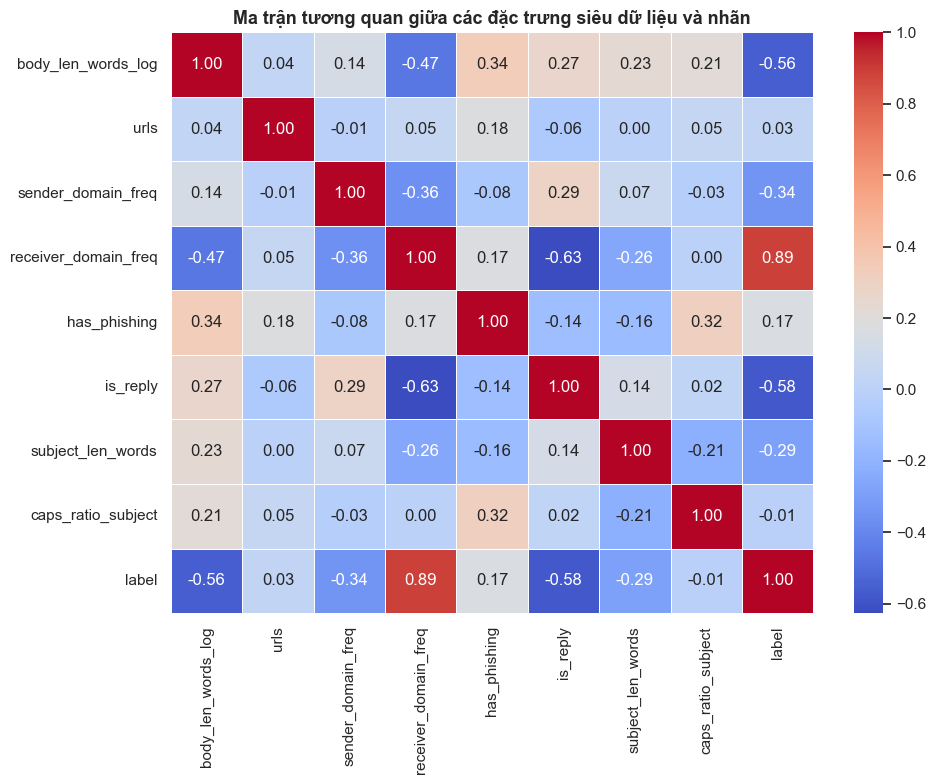

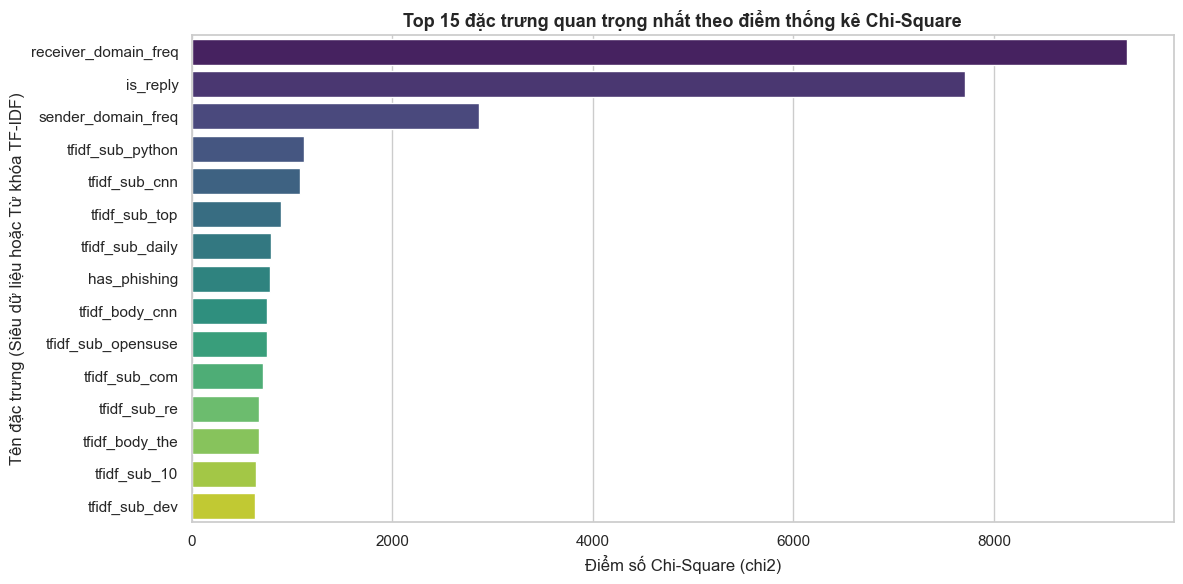

Kích thước dữ liệu sau khi lựa chọn đặc trưng:
  - X_train_final.shape: (31323, 3500)
  - X_test_final.shape : (7831, 3500)

Top 15 đặc trưng có điểm Chi-Square cao nhất:
  1. receiver_domain_freq               : 9328.6084
  2. is_reply                           : 7707.9101
  3. sender_domain_freq                 : 2870.0256
  4. tfidf_sub_python                   : 1124.1017
  5. tfidf_sub_cnn                      : 1076.2809
  6. tfidf_sub_top                      : 894.1513
  7. tfidf_sub_daily                    : 787.4420
  8. has_phishing                       : 778.4101
  9. tfidf_body_cnn                     : 752.5935
  10. tfidf_sub_opensuse                 : 751.4742
  11. tfidf_sub_com                      : 715.5389
  12. tfidf_sub_re                       : 675.7057
  13. tfidf_body_the                     : 672.6811
  14. tfidf_sub_10                       : 646.9882
  15. tfidf_sub_dev                      : 633.2831


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import SelectKBest, chi2
import scipy.sparse as sp
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import time

print("=== BƯỚC 6: LỰA CHỌN ĐẶC TRƯNG, THỰC NGHIỆM ĐỐI SÁNH & LƯU TRỮ ===")

# 6a. Trực quan hóa Ma trận tương quan các đặc trưng siêu dữ liệu
train_meta_scaled_df = pd.DataFrame(X_train_meta_scaled, columns=meta_cols, index=train_data.index)
train_meta_scaled_df['label'] = y_train
corr_matrix = train_meta_scaled_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Ma trận tương quan giữa các đặc trưng siêu dữ liệu và nhãn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 6b. Thực hiện lựa chọn đặc trưng bằng SelectKBest & Chi-Square (k=3500 để khớp với mô hình đã lưu)
selector = SelectKBest(chi2, k=3500)
X_train_final = selector.fit_transform(X_train_combined, y_train)
X_test_final = selector.transform(X_test_combined)

# 6c. Trực quan hóa điểm số Chi-Square của Top 15 đặc trưng tốt nhất
scores = selector.scores_
indices = np.argsort(scores)[::-1]
top_n = 15
top_indices = indices[:top_n]
sorted_features = [all_feature_names[i] for i in top_indices]
sorted_scores = scores[top_indices]

plt.figure(figsize=(12, 6))
sns.barplot(x=sorted_scores, y=sorted_features, palette='viridis', hue=sorted_features, legend=False)
plt.title('Top 15 đặc trưng quan trọng nhất theo điểm thống kê Chi-Square', fontsize=13, fontweight='bold')
plt.xlabel('Điểm số Chi-Square (chi2)')
plt.ylabel('Tên đặc trưng (Siêu dữ liệu hoặc Từ khóa TF-IDF)')
plt.tight_layout()
plt.show()

print(f"Kích thước dữ liệu sau khi lựa chọn đặc trưng:")
print(f"  - X_train_final.shape: {X_train_final.shape}")
print(f"  - X_test_final.shape : {X_test_final.shape}")

print("\nTop 15 đặc trưng có điểm Chi-Square cao nhất:")
for rank, (name, val) in enumerate(zip(sorted_features, sorted_scores), 1):
    print(f"  {rank}. {name:<35}: {val:.4f}")


=== TIẾN HÀNH THỰC NGHIỆM ĐỐI SÁNH LOẠI TRỪ (ABLATION STUDY) ===

--- Mức 1: Có Metadata + Chọn lọc đặc trưng (k=3500) ---

--- Mức 2: Có Metadata + Không Chọn lọc đặc trưng (k=Full) ---

--- Mức 3: Chỉ TF-IDF thô + Không Chọn lọc đặc trưng (k=Full) ---

================ BẢNG KẾT QUẢ THỰC NGHIỆM ĐỐI SÁNH ================
                                   Kịch bản  Số Đặc Trưng  Accuracy  Precision  F1-Score      TPR      FPR  Thời gian train (ms)
         1. Có Metadata + Chọn lọc (k=3500)          3500  0.950198   0.923388  0.956992 0.993133 0.103986             55.158138
   2. Có Metadata + Không Chọn lọc (k=Full)          5628  0.950326   0.923585  0.957097 0.993133 0.103697             73.117256
3. Chỉ TF-IDF thô + Không Chọn lọc (k=Full)          5620  0.919934   0.905505  0.930201 0.956283 0.125939             74.546337


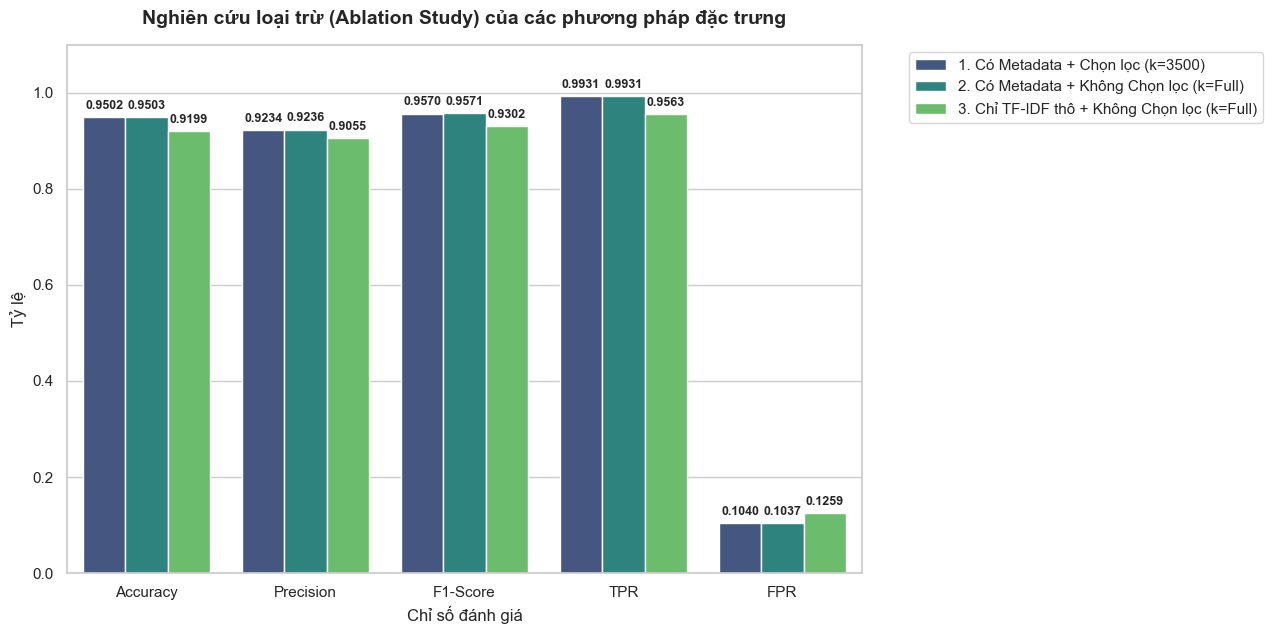


Đã lưu thành công dữ liệu đặc trưng và nhãn!


In [27]:
print("=== TIẾN HÀNH THỰC NGHIỆM ĐỐI SÁNH LOẠI TRỪ (ABLATION STUDY) ===")

import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix
import scipy.sparse as sp
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import SGDClassifier

results = []

# ================= MỨC 1: ĐẦY ĐỦ CẢ 3 (METADATA + GENERATION + SELECTION k=3500) =================
print("\n--- Mức 1: Có Metadata + Chọn lọc đặc trưng (k=3500) ---")
model_case1 = SGDClassifier(loss='log_loss', max_iter=20, alpha=0.01, learning_rate='constant', eta0=0.1, random_state=42)
t0 = time.time()
model_case1.fit(X_train_final, y_train)
fit_time = (time.time() - t0) * 1000
y_pred_case1 = model_case1.predict(X_test_final)

# Tính toán TPR và FPR từ Confusion Matrix
tn1, fp1, fn1, tp1 = confusion_matrix(y_test, y_pred_case1).ravel()
tpr1 = tp1 / (tp1 + fn1)
fpr1 = fp1 / (fp1 + tn1)

results.append({
    'Kịch bản': '1. Có Metadata + Chọn lọc (k=3500)',
    'Số Đặc Trưng': X_train_final.shape[1],
    'Accuracy': accuracy_score(y_test, y_pred_case1),
    'Precision': precision_score(y_test, y_pred_case1),
    'F1-Score': f1_score(y_test, y_pred_case1),
    'TPR': tpr1,
    'FPR': fpr1,
    'Thời gian train (ms)': fit_time
})

# ================= MỨC 2: BỎ CHỌN LỌC ĐẶC TRƯNG (METADATA + GENERATION, k=Full) =================
print("\n--- Mức 2: Có Metadata + Không Chọn lọc đặc trưng (k=Full) ---")
model_case2 = SGDClassifier(loss='log_loss', max_iter=20, alpha=0.01, learning_rate='constant', eta0=0.1, random_state=42)
t0 = time.time()
model_case2.fit(X_train_combined, y_train)
fit_time = (time.time() - t0) * 1000
y_pred_case2 = model_case2.predict(X_test_combined)

# Tính toán TPR và FPR từ Confusion Matrix
tn2, fp2, fn2, tp2 = confusion_matrix(y_test, y_pred_case2).ravel()
tpr2 = tp2 / (tp2 + fn2)
fpr2 = fp2 / (fp2 + tn2)

results.append({
    'Kịch bản': '2. Có Metadata + Không Chọn lọc (k=Full)',
    'Số Đặc Trưng': X_train_combined.shape[1],
    'Accuracy': accuracy_score(y_test, y_pred_case2),
    'Precision': precision_score(y_test, y_pred_case2),
    'F1-Score': f1_score(y_test, y_pred_case2),
    'TPR': tpr2,
    'FPR': fpr2,
    'Thời gian train (ms)': fit_time
})

# ================= MỨC 3: BỎ CẢ CHỌN LỌC VÀ METADATA (CHỈ CÓ TF-IDF THÔ, k=Full) =================
print("\n--- Mức 3: Chỉ TF-IDF thô + Không Chọn lọc đặc trưng (k=Full) ---")
n_meta = X_train_meta_scaled.shape[1]
X_train_tfidf_only = X_train_combined[:, :-n_meta]
X_test_tfidf_only = X_test_combined[:, :-n_meta]

model_case3 = SGDClassifier(loss='log_loss', max_iter=20, alpha=0.01, learning_rate='constant', eta0=0.1, random_state=42)
t0 = time.time()
model_case3.fit(X_train_tfidf_only, y_train)
fit_time = (time.time() - t0) * 1000
y_pred_case3 = model_case3.predict(X_test_tfidf_only)

# Tính toán TPR và FPR từ Confusion Matrix
tn3, fp3, fn3, tp3 = confusion_matrix(y_test, y_pred_case3).ravel()
tpr3 = tp3 / (tp3 + fn3)
fpr3 = fp3 / (fp3 + tn3)

results.append({
    'Kịch bản': '3. Chỉ TF-IDF thô + Không Chọn lọc (k=Full)',
    'Số Đặc Trưng': X_train_tfidf_only.shape[1],
    'Accuracy': accuracy_score(y_test, y_pred_case3),
    'Precision': precision_score(y_test, y_pred_case3),
    'F1-Score': f1_score(y_test, y_pred_case3),
    'TPR': tpr3,
    'FPR': fpr3,
    'Thời gian train (ms)': fit_time
})

# ----------------- IN BẢNG KẾT QUẢ ĐỐI SÁNH SẠCH SẼ -----------------
df_results = pd.DataFrame(results)
print("\n================ BẢNG KẾT QUẢ THỰC NGHIỆM ĐỐI SÁNH ================")
print(df_results.to_string(index=False))

# ----------------- TRỰC QUAN HÓA KẾT QUẢ BẰNG BIỂU ĐỒ GỌN GÀNG -----------------
# Loại bỏ 'Recall' khỏi value_vars để tránh trùng lặp
df_melt = pd.melt(df_results, id_vars=['Kịch bản'], 
                  value_vars=['Accuracy', 'Precision', 'F1-Score', 'TPR', 'FPR'], 
                  var_name='Chỉ số', value_name='Tỷ lệ')

plt.figure(figsize=(13, 6.5))
sns.set_theme(style="whitegrid")
ax = sns.barplot(data=df_melt, x='Chỉ số', y='Tỷ lệ', hue='Kịch bản', palette='viridis')

# Hiển thị số liệu cụ thể trên đầu mỗi cột
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f"{height:.4f}", (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=9, fontweight='bold')

plt.title('Nghiên cứu loại trừ (Ablation Study) của các phương pháp đặc trưng', fontsize=14, fontweight='bold', pad=15)
plt.ylim(0.0, 1.1)  # Giữ từ 0.0 để thấy rõ sự chênh lệch thấp của FPR (Càng gần 0 càng tốt)
plt.ylabel('Tỷ lệ')
plt.xlabel('Chỉ số đánh giá')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Lưu dữ liệu đặc trưng và nhãn
sp.save_npz('../data/ready_train/X_train_final.npz', X_train_final)
sp.save_npz('../data/ready_train/X_test_final.npz', X_test_final)
y_train.to_pickle('../data/ready_train/y_train.pkl')
y_test.to_pickle('../data/ready_train/y_test.pkl')
print("\nĐã lưu thành công dữ liệu đặc trưng và nhãn!")

In [ ]:
# Lưu gói tiền xử lý đặc trưng
import pickle

preprocess_pack = {
    'tfidf_sub': tfidf_sub,
    'tfidf_msg': tfidf_msg,
    'scaler': scaler,
    'selector': selector,
    'sender_freq': sender_freq.to_dict(),
    'receiver_freq': receiver_freq.to_dict()
}

with open('../data/ready_train/preprocess_pack.pkl', 'wb') as f:
    pickle.dump(preprocess_pack, f)
    
print("Đã lưu thành công bộ tiền xử lý đặc trưng (preprocess_pack.pkl)!")

Đã lưu thành công bộ tiền xử lý đặc trưng (preprocess_pack.pkl)!
